# Import datase

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/hcvdat0.csv', delimiter=',')
# بررسی تعداد مقادیر گمشده
print(df.isnull().sum())
df

index        0
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64


,index,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,611,3=Cirrhosis,62,f,32.0,416.6,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
611,612,3=Cirrhosis,64,f,24.0,102.8,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3
612,613,3=Cirrhosis,64,f,29.0,87.3,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82.0
613,614,3=Cirrhosis,46,f,33.0,NaN,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocess : Median Imputation

In [ ]:
df_imputed = df.copy()
columns = ["Age",	"ALB",	"ALP",	"ALT",	"AST",	"BIL",	"CHE",	"CHOL",	"CREA",	"GGT",	"PROT"]
for column in columns:
    median_value = df[column].median()
    df_imputed.fillna({column : median_value}, inplace=True)  #جایگزینی مقادیر گمشده با میانه
df_imputed

,index,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,611,3=Cirrhosis,62,f,32.0,416.6,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
611,612,3=Cirrhosis,64,f,24.0,102.8,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3
612,613,3=Cirrhosis,64,f,29.0,87.3,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82.0
613,614,3=Cirrhosis,46,f,33.0,66.2,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71.0


# Preprocess : Data Standardization

In [ ]:
df = df_imputed
# ---------- حذف ستون index ----------
df = df.drop(columns=['index'])

# ---------- تبدیل برچسب هدف (Category) به 0/1 ----------
df['Category'] = np.where(df['Category'] == '0=Blood Donor', 0, 1)
#df['Category'] = df['Category'].apply(lambda x: 0 if x[0] == '0' else 1)

# ---------- تبدیل جنسیت به عدد ----------
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})

df.astype(float)

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0.0,32.0,1.0,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0.0,32.0,1.0,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0.0,32.0,1.0,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0.0,32.0,1.0,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0.0,32.0,1.0,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,1.0,62.0,0.0,32.0,416.6,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
611,1.0,64.0,0.0,24.0,102.8,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3
612,1.0,64.0,0.0,29.0,87.3,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82.0
613,1.0,46.0,0.0,33.0,66.2,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71.0


In [ ]:
# ---------- جدا کردن ویژگی‌ها و هدف ----------
df = df.drop_duplicates()
x = df.drop('Category', axis=1)
y = df['Category']

In [ ]:
x.head()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
y.head()

,Category
0,0
1,0
2,0
3,0
4,0


# Train & Test split

In [ ]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y)

In [ ]:
x_train_raw.shape, x_test_raw.shape
x_train_raw

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
7,32,1,42.2,41.9,35.8,31.1,16.1,5.82,4.60,109.0,21.5,67.1
410,46,0,32.4,56.5,23.8,24.8,6.4,8.22,5.19,64.0,11.0,72.0
453,51,0,37.8,80.7,32.9,27.3,6.2,7.29,5.26,68.0,27.1,70.6
468,52,0,40.2,89.7,26.8,19.1,6.9,9.10,7.04,75.0,41.6,67.4
520,61,0,38.1,66.4,11.8,22.7,6.8,6.35,6.55,65.0,14.5,78.9
...,...,...,...,...,...,...,...,...,...,...,...,...
514,60,0,40.5,86.0,26.0,27.6,5.7,8.60,4.90,58.0,20.1,71.7
448,50,0,42.5,74.0,10.9,23.0,4.6,9.42,6.33,76.0,9.0,68.8
210,51,1,42.0,84.3,14.7,19.2,3.2,8.19,4.68,81.0,20.9,77.1
418,46,0,51.3,84.1,40.6,43.6,9.2,7.10,5.62,62.0,74.9,77.1


In [ ]:
y_train

,Category
7,0
410,0
453,0
468,0
520,0
...,...
514,0
448,0
210,0
418,0


# Feature Selection

In [ ]:
!pip install pymrmr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pymrmr: filename=pymrmr-0.1.11-cp311-cp311-linux_x86_64.whl size=401298 sha256=9ac488ecf37e31478559cee3c092fc9eab092ba707d46187a81d4bb3c9a67f0e
  Stored in directory: /root/.cache/pip/wheels/a0/d7/97/71bca023a0dbdceab24a556649d661e71114f4eaaf4dda56d6
Successfully built pymrmr


In [ ]:
import pymrmr
df_train = pd.concat([x_train_raw, y_train], axis=1)

df_train = df_train.astype(float)

selected_features = pymrmr.mRMR(df_train, 'MIQ', 6)
selected_features_mRMR = selected_features
print(selected_features_mRMR)

['ALP', 'GGT', 'CREA', 'AST', 'ALT', 'ALB']


# Preprocess: Min-Max, L1, L2  Normalization

In [42]:
from sklearn.preprocessing import MinMaxScaler , Normalizer
df = df[[col for col in df.columns if col != 'Category'] + ['Category']]

scaler = MinMaxScaler()
xtrain_n = scaler.fit_transform(x_train_raw)
xtest_n = scaler.transform(x_test_raw)
x_train = pd.DataFrame(xtrain_n, columns=x_train_raw.columns,index=x_train_raw.index)
x_test = pd.DataFrame(xtest_n, columns=x_test_raw.columns,index=x_test_raw.index)
norm = scaler.fit_transform(df)
df_norm = pd.DataFrame(norm, columns=df.columns,index=df.index)
df_norm

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,AST_ALT,Category
0,0.224138,1.0,0.350669,0.101653,0.020962,0.036694,0.026461,0.367578,0.218447,0.091495,0.011757,0.535398,0.027691,0.0
1,0.224138,1.0,0.350669,0.145571,0.052713,0.044990,0.012243,0.650434,0.408981,0.061619,0.017172,0.701327,0.010825,0.0
2,0.224138,1.0,0.475483,0.156427,0.108816,0.134014,0.020932,0.494997,0.457524,0.072822,0.044400,0.763274,0.011735,0.0
3,0.224138,1.0,0.420505,0.100419,0.091554,0.038290,0.071485,0.394263,0.401699,0.067221,0.045328,0.683628,0.003690,0.0
4,0.224138,1.0,0.361070,0.154947,0.097719,0.045310,0.034755,0.515677,0.350728,0.063486,0.039295,0.528761,0.003940,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,0.741379,0.0,0.254086,1.000000,0.015413,0.318124,0.194313,0.276851,0.591019,0.044534,1.000000,0.524336,0.205875,1.0
611,0.775862,0.0,0.135215,0.225759,0.006165,0.107849,0.075829,0.008005,0.192961,0.051349,0.048577,0.586283,0.167766,1.0
612,0.775862,0.0,0.209510,0.187515,0.008015,0.282068,0.186414,0.016011,0.266990,0.054803,0.092358,0.823009,0.313866,1.0
613,0.465517,0.0,0.268945,0.135455,0.117448,0.164008,0.075829,0.142762,0.336165,0.041079,0.070390,0.579646,0.013274,1.0


# Heatmap of feature correlation

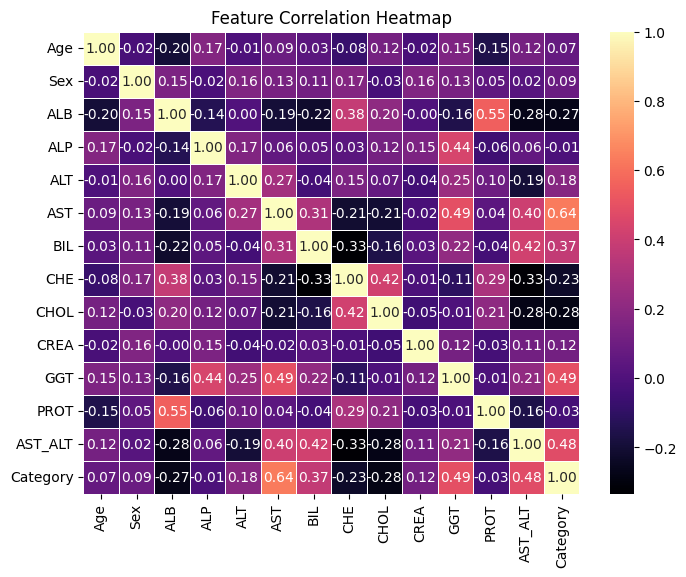

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt


correlation_matrix = df_norm.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
!pip install scikit-learn

# Train, Test and Performance Evaluation

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Performance for KNN:
Accuracy: 0.9081
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       160
           1       1.00      0.32      0.48        25

    accuracy                           0.91       185
   macro avg       0.95      0.66      0.72       185
weighted avg       0.92      0.91      0.89       185

Confusion Matrix:
[[160   0]
 [ 17   8]]
Performance for Decision Tree:
Accuracy: 0.9405
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       160
           1       0.77      0.80      0.78        25

    accuracy                           0.94       185
   macro avg       0.87      0.88      0.87       185
weighted avg       0.94      0.94      0.94       185

Confusion Matrix:
[[154   6]
 [  5  20]]
Performance for SVM:
Accuracy: 0.9676
Classification Re

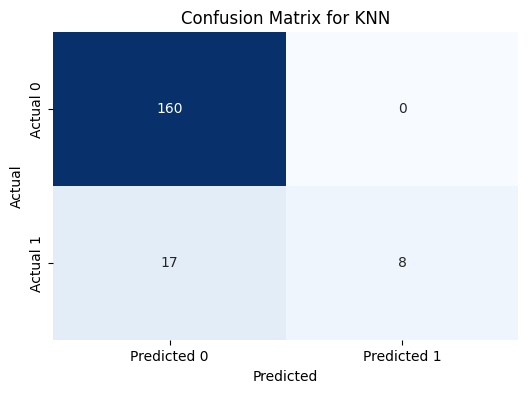

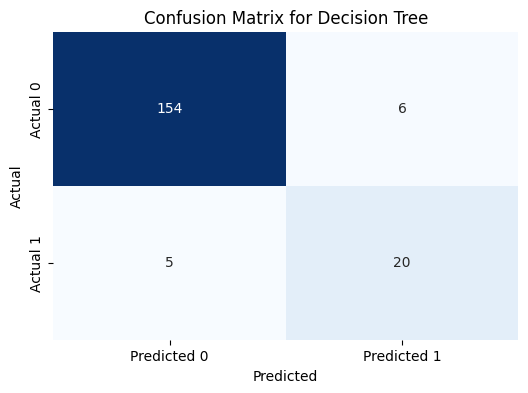

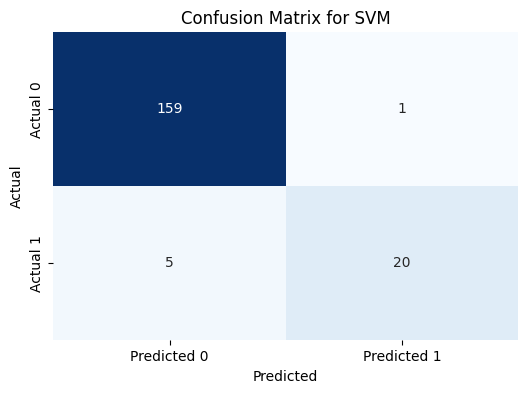

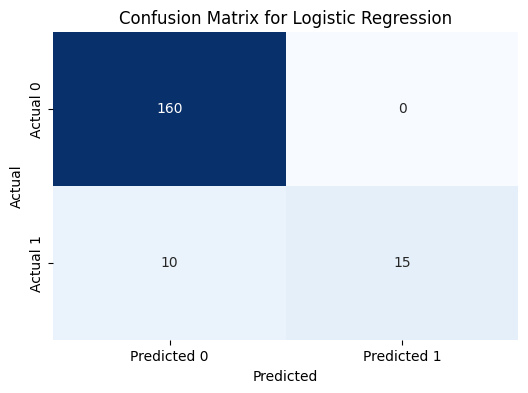

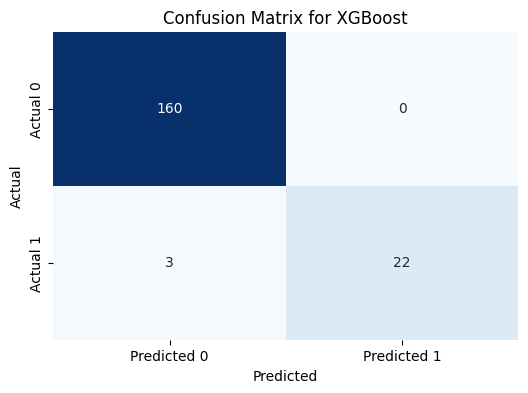

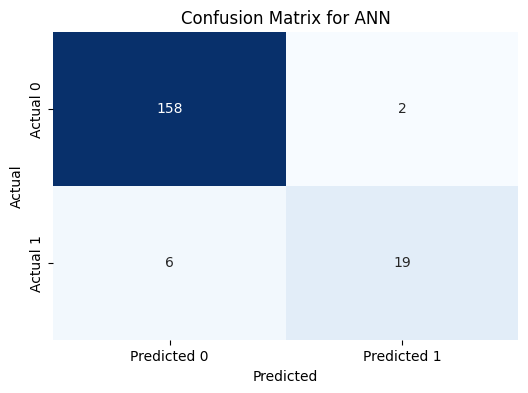

In [44]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

models = {
    "KNN":  KNeighborsClassifier(n_neighbors=10),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(C=10, gamma=1, kernel='rbf',
                     probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(C=10, penalty='l2',
                                    solver='lbfgs', max_iter=1000),
    "XGBoost": xgb.XGBClassifier(objective='binary:logistic',
                                   eval_metric='logloss',
                                   learning_rate=0.2, random_state=42)
}

importances = {}
performance = {}

# Fit models and compute feature importance
for model_name, model in models.items():
    model.fit(x_train, y_train)

    y_pred_t = model.predict(x_train)
    y_pred = model.predict(x_test)

    # Compute accuracy score on the test set
    accuracy = accuracy_score(y_test, y_pred)

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Compute MAE for train and test sets
    mae_train = mean_absolute_error(y_train, y_pred_t)
    mae_test = mean_absolute_error(y_test, y_pred)

    # Store performance metrics
    performance[model_name] = {
        "Accuracy": accuracy,
        "Classification Report": classification_report(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "mae_test":mae_test,
        "mae_train":mae_train
    }

    if model_name == "Decision Tree" or model_name == "XGBoost":
        # For tree-based models (Decision Tree, XGBoost), use feature_importances_
        importances[model_name] = model.feature_importances_
    elif model_name == "Logistic Regression":
        # For Logistic Regression, use coefficients for feature importance
        importances[model_name] = np.abs(model.coef_[0])

# Add ANN model
# Build the ANN Model
ann_model = Sequential([
    Dense(64, input_dim=x_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])
# Compile the ANN Model
ann_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the ANN Model
ann_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32, verbose=0)

# Evaluate the ANN Model
y_pred_t = (ann_model.predict(x_train) > 0.5).astype(int)
y_pred = (ann_model.predict(x_test) > 0.5).astype(int)

# Compute accuracy score on the test set
accuracy = accuracy_score(y_test, y_pred)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Compute MAE for train and test sets
mae_train = mean_absolute_error(y_train, y_pred_t)
mae_test = mean_absolute_error(y_test, y_pred)

# Store performance metrics
performance["ANN"] = {
    "Accuracy": accuracy,
    "Classification Report": classification_report(y_test, y_pred),
    "Confusion Matrix": confusion_matrix(y_test, y_pred),
    "fpr": fpr,
    "tpr": tpr,
    "roc_auc": roc_auc,
    "mae_test": mae_test,
    "mae_train": mae_train
}

for model_name, metrics in performance.items():
    print(f"Performance for {model_name}:")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Classification Report:\n{metrics['Classification Report']}")
    print(f"Confusion Matrix:\n{metrics['Confusion Matrix']}")
    print("="*50)

importance_df = pd.DataFrame(importances,index=x.columns)

importance_df_normalized = importance_df / importance_df.sum()

importance_df_normalized['Average'] = importance_df_normalized.mean(axis=1)

importance_df_normalized = importance_df_normalized.sort_values(by='Average', ascending=False)['Average']

print(importance_df_normalized)

import seaborn as sns
import matplotlib.pyplot as plt

# Add confusion matrix plot
for model_name, metrics in performance.items():
    cm = metrics["Confusion Matrix"]

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
for model_name, metrics in performance.items():
    print(f"Performance for {model_name}:")
    print(f"MAE on Training Set: {metrics['mae_train']:.2f}")
    print(f"MAE on Test Set: {metrics['mae_test']:.2f}")
    print()
    print("="*50)
    print()

Performance for KNN:
MAE on Training Set: 0.11
MAE on Test Set: 0.09


Performance for Decision Tree:
MAE on Training Set: 0.00
MAE on Test Set: 0.06


Performance for SVM:
MAE on Training Set: 0.03
MAE on Test Set: 0.03


Performance for Logistic Regression:
MAE on Training Set: 0.07
MAE on Test Set: 0.05


Performance for XGBoost:
MAE on Training Set: 0.00
MAE on Test Set: 0.02


Performance for ANN:
MAE on Training Set: 0.03
MAE on Test Set: 0.04




In [ ]:
!pip install optuna
import pandas as pd, numpy as np, xgboost as xgb, optuna, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import RFECV

warnings.filterwarnings('ignore')

# ---------- Feature Engineering ----------
df['AST_ALT'] = df['AST'] / (df['ALT'] + 1e-6)

X = df.drop('Category', axis=1)
y = df['Category']

# ---------- Oversample minority with SMOTE ----------
smote = SMOTE(random_state=42)

# ---------- Wrapper function for Optuna ----------
def xgb_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('lr', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': 6,  # تقریباً 150 / 25
        'n_estimators': 800,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }

    #  SMOTE → StandardScaler → XGB
    model = ImbPipeline(steps=[
        ('smote', smote),
        ('scaler', StandardScaler(with_mean=False)),  # XGB نیاز سخت به مقیاس ندارد ولی برای RFE مفید است
        ('xgb',   xgb.XGBClassifier(**params))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    return 1.0 - auc   # Optuna حداقل می‌کند

study = optuna.create_study(direction='minimize')
study.optimize(xgb_objective, n_trials=60, timeout=900)

best_params = study.best_trial.params
best_params.update({
    'n_estimators': 800,
    'scale_pos_weight': 6,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
})

[I 2025-07-04 17:38:33,634] A new study created in memory with name: no-name-4e53e51d-d729-4835-8b03-4547bea4a311
[I 2025-07-04 17:38:38,098] Trial 0 finished with value: 0.017214387959380573 and parameters: {'lr': 0.016405243479201703, 'max_depth': 6, 'min_child_weight': 4, 'gamma': 2.0200069111114427, 'subsample': 0.9685267726109152, 'colsample': 0.9617692600932195, 'reg_lambda': 4.197639688823607}. Best is trial 0 with value: 0.017214387959380573.
[I 2025-07-04 17:38:39,027] Trial 1 finished with value: 0.017436363542066458 and parameters: {'lr': 0.04441516149019842, 'max_depth': 6, 'min_child_weight': 4, 'gamma': 0.8038231851609456, 'subsample': 0.9938430690293568, 'colsample': 0.7973203552099308, 'reg_lambda': 2.1535943740596037}. Best is trial 0 with value: 0.017214387959380573.
[I 2025-07-04 17:38:39,974] Trial 2 finished with value: 0.020619872000995798 and parameters: {'lr': 0.01600193500044596, 'max_depth': 5, 'min_child_weight': 10, 'gamma': 3.5818944305383953, 'subsample': 

In [ ]:
# ---------- RFE با پارامترهای بهینه ----------
base_xgb = xgb.XGBClassifier(**best_params)

rfe = RFECV(
    estimator=base_xgb,      # مدل پایه
    step=1,                  # هر بار ۱ ویژگی حذف شود
    scoring='roc_auc',       # معیار ارزیابی = AUC
    cv=StratifiedKFold(5),   # ۵‑fold CV برای ارزیابی
    n_jobs=-1,               # استفاده از تمام هسته‌ها
    min_features_to_select=5 # حداقل ۵ ویژگی نگه داشته شود
)

rfe.fit(X, y)
selected_features = X.columns[rfe.support_]
print("Selected features:", list(selected_features))

# ---------- مدل نهایی با ویژگی‌های انتخاب‌شده ----------
X_sel = X[selected_features]
x_train,x_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.3, stratify=y, random_state=42)

final_xgb = xgb.XGBClassifier(**best_params, early_stopping_rounds=None)
pipeline_final = ImbPipeline([
    ('smote', smote),
    ('xgb',   final_xgb)
])
pipeline_final.fit(x_train, y_train)

y_pred  = pipeline_final.predict(x_test)
y_proba = pipeline_final.predict_proba(x_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"AUC      : {auc:.4f}")



Selected features: ['Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT', 'AST_ALT']
Accuracy : 0.9838
AUC      : 0.9995


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
preds = np.zeros_like(y_test, dtype=float)

for train_idx, val_idx in folds.split(X_sel, y):
    X_tr, y_tr = X_sel.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X_sel.iloc[val_idx], y.iloc[val_idx]

    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    params = best_params.copy()
    params.pop('n_estimators', None)  # حذف در صورت وجود

    model = xgb.XGBClassifier(**params, n_estimators=800)
    model.fit(X_tr_res, y_tr_res)

    preds += model.predict_proba(x_test)[:,1] / folds.n_splits
y_hat = (preds >= 0.5).astype(int)
print("Ensemble Accuracy:", accuracy_score(y_test, y_hat))
print("Ensemble   AUC  :", roc_auc_score(y_test, preds))


Ensemble Accuracy: 1.0
Ensemble   AUC  : 1.0
